# SIT307/SIT720 - Task 8.1D
# Sydney Housing Price Prediction: Parts 2-4

This notebook covers **Part 2 (Data Understanding and Feature Engineering)**,
**Part 3 (Model Development and Evaluation)** and **Part 4 (Investigating Prediction Failures)**.

The dataset was constructed manually from sold listings on domain.com.au across three
Sydney suburbs: **Blacktown (2148)**, **Parramatta (2150)** and **Chatswood (2067)**.
Part 1 (problem definition, suburb motivation and data collection) and Part 5
(Streamlit deployment) are covered in the report and in `app.py` respectively.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("pandas     ", pd.__version__)
print("numpy      ", np.__version__)
print("scikit-learn", sklearn.__version__)

pandas      3.0.2
numpy       2.4.4
scikit-learn 1.8.0


## 1. Load the dataset

`sydney_housing_data_clean.xlsx` holds the 110 collected sales. The `Agent description`
column is a shortened version of the original listing text; the full original text is kept
in the `Agent descriptions (raw)` sheet for transparency. The `f_*` columns are binary
features extracted from the **original** description text using keyword rules (see Section 4).

In [2]:
PATH = "sydney_housing_data_clean.xlsx"
df = pd.read_excel(PATH, sheet_name="sydney_housing_data")
print("shape:", df.shape)
df.head(3)

shape: (110, 30)


,Suburb,Postcode,Address,Property type,Bedrooms,Bathrooms,Car spaces,Land size (sqm),Internal area (sqm),Sold price,...,f_private_pool,f_complex_facilities,f_near_transport,f_premium_finish,f_period_character,f_ensuite,f_ducted_ac,f_study_extra_living,f_alfresco,desc_word_count_original
0,Parramatta,2150,"4/44-50 Thomas Street, Parramatta",Townhouse,2,1,1.0,128.0,NaN,720000,...,0,0,0,0,0,0,0,0,0,61
1,Parramatta,2150,"2315/45 Macquarie Street, Parramatta",Apartment / Unit / Flat,2,2,1.0,NaN,NaN,640000,...,0,1,0,1,0,0,1,0,0,403
2,Parramatta,2150,"1/3 Stewart Street, Parramatta",Apartment / Unit / Flat,2,1,1.0,NaN,NaN,570000,...,0,0,1,0,0,0,0,0,0,217


In [3]:
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Suburb                                 str
Postcode                             int64
Address                                str
Property type                          str
Bedrooms                             int64
Bathrooms                            int64
Car spaces                         float64
Land size (sqm)                    float64
Internal area (sqm)                float64
Sold price                           int64
Sold date                   datetime64[us]
Sale method                            str
Listing url                            str
Agent description                      str
f_renovated                          int64
f_brand_new                          int64
f_needs_work                         int64
f_dev_potential                      int64
f_granny_flat                        int64
f_view                               int64
f_private_pool                       int64
f_complex_facilities                 int64
f_near_transport                     int64
f_premium_f

## 2. Data cleaning decisions

Three cleaning decisions were made before any analysis, each recorded here so the
notebook is reproducible.

**2.1 Drop `Internal area (sqm)`.** The column is empty for all 110 rows. Domain does not
display internal floor area on its sold-listing result cards; obtaining it would require
opening each floor plan individually. The column carries no information and is removed.

**2.2 Consolidate `Property type` into three groups.** The raw Domain labels include
categories with only one or two observations (Villa = 1, Duplex = 1, Semi-detached = 2).
One-hot encoding these directly would create near-singleton indicator columns that a
flexible model can memorise, and would make "Duplex" appear to be the most expensive
property type in Sydney on the strength of a single $4.22m sale. The labels are collapsed
into **House**, **Unit** (apartment/unit/flat) and **Attached** (townhouse, semi-detached,
villa, duplex).

**2.3 Treat missing `Land size (sqm)` as *not applicable* rather than *missing*.**
52 of 110 rows have no land size, but the missingness is structural rather than random:
37 of 51 units have none, because a strata apartment has no individual land title.
Among houses only 9 of 48 are missing. Imputing a land size for an apartment would be
meaningless, so instead a binary `has_land` indicator is created and land size is set to
zero where the concept does not apply. Genuinely missing values within House and Attached
are imputed with the median for that group.

In [4]:
df = df.drop(columns=["Internal area (sqm)"])

TYPE_MAP = {
    "House": "House",
    "Apartment / Unit / Flat": "Unit",
    "Townhouse": "Attached",
    "Semi-detached": "Attached",
    "Villa": "Attached",
    "Duplex": "Attached",
}
df["type_group"] = df["Property type"].map(TYPE_MAP)
assert df["type_group"].notna().all(), "unmapped property type"

print(pd.crosstab(df["Property type"], df["type_group"]))
print()
print(df["type_group"].value_counts())

type_group               Attached  House  Unit
Property type                                 
Apartment / Unit / Flat         0      0    51
Duplex                          1      0     0
House                           0     48     0
Semi-detached                   2      0     0
Townhouse                       7      0     0
Villa                           1      0     0

type_group
Unit        51
House       48
Attached    11
Name: count, dtype: int64


In [5]:
# --- Land size: not applicable vs genuinely missing ---
land = df["Land size (sqm)"]

# A unit has no individual land title -> "not applicable"
not_applicable = df["type_group"].eq("Unit") & land.isna()
# House / Attached with no figure shown -> genuinely missing, impute by group median
genuinely_missing = ~df["type_group"].eq("Unit") & land.isna()

print(f"not applicable (Unit)      : {not_applicable.sum()}")
print(f"genuinely missing          : {genuinely_missing.sum()}")

df["has_land"] = (~df["type_group"].eq("Unit")).astype(int)

med = df.loc[df["type_group"].ne("Unit")].groupby("type_group")["Land size (sqm)"].median()
print("\nGroup medians used for imputation:")
print(med)

df["land_size"] = land.copy()
df.loc[not_applicable, "land_size"] = 0.0
for g, m in med.items():
    sel = genuinely_missing & df["type_group"].eq(g)
    df.loc[sel, "land_size"] = m
df["land_imputed"] = (genuinely_missing | not_applicable).astype(int)

assert df["land_size"].notna().all()
print("\nland_size summary by group:")
print(df.groupby("type_group")["land_size"].describe()[["count", "mean", "50%", "max"]])

not applicable (Unit)      : 37
genuinely missing          : 15

Group medians used for imputation:
type_group
Attached    156.0
House       563.0
Name: Land size (sqm), dtype: float64

land_size summary by group:
            count        mean    50%     max
type_group                                  
Attached     11.0  207.181818  156.0   614.0
House        48.0  587.520833  563.0  1182.0
Unit         51.0  228.313725    0.0  3733.0


In [6]:
# Car spaces: a dash on the listing card means "not stated", not zero.
print("Car spaces missing:", df["Car spaces"].isna().sum())
df["car_spaces"] = df["Car spaces"].fillna(df["Car spaces"].median())
df["car_imputed"] = df["Car spaces"].isna().astype(int)

df["Sold date"] = pd.to_datetime(df["Sold date"])
latest = df["Sold date"].max()
df["months_before_latest"] = ((latest - df["Sold date"]).dt.days / 30.44).round(2)
print("\nCollection window:", df["Sold date"].min().date(), "to", latest.date())
print(df.groupby("Suburb")["Sold date"].agg(["min", "max", "count"]))

Car spaces missing: 4

Collection window: 2025-09-27 to 2026-09-18
                  min        max  count
Suburb                                 
Blacktown  2026-08-14 2026-09-18     36
Chatswood  2026-06-05 2026-09-01     40
Parramatta 2025-09-27 2026-09-16     34


## 3. Part 2: Exploratory data analysis

### 3.1 The distribution of sale prices

In [7]:
print(df["Sold price"].describe().apply(lambda v: f"{v:,.0f}"))
print()
print("Skewness (raw price)     :", round(df["Sold price"].skew(), 3))
print("Skewness (log price)     :", round(np.log(df["Sold price"]).skew(), 3))

count          110
mean     1,397,723
std      1,001,669
min        320,000
25%        719,250
50%      1,102,500
75%      1,708,125
max      6,200,000
Name: Sold price, dtype: str

Skewness (raw price)     : 1.996
Skewness (log price)     : 0.243


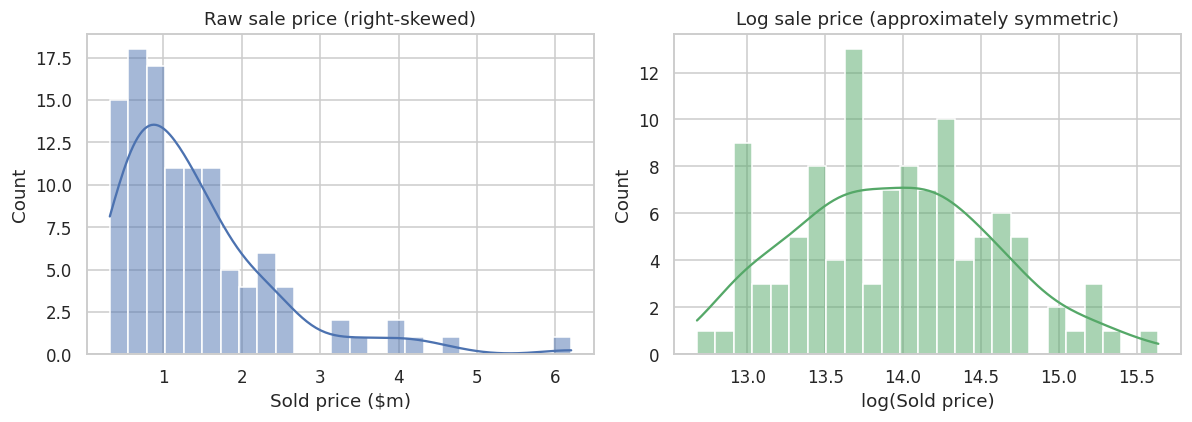

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["Sold price"] / 1e6, bins=25, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("Sold price ($m)"); axes[0].set_ylabel("Count")
axes[0].set_title("Raw sale price (right-skewed)")

sns.histplot(np.log(df["Sold price"]), bins=25, kde=True, ax=axes[1], color="#55A868")
axes[1].set_xlabel("log(Sold price)"); axes[1].set_ylabel("Count")
axes[1].set_title("Log sale price (approximately symmetric)")
plt.tight_layout(); plt.show()

Raw prices are strongly right-skewed: the range runs from \$320,000 to \$6,200,000, so the
most expensive sale is roughly 19 times the cheapest. Taking logs brings the skewness close
to zero and makes the distribution roughly symmetric.

**All models below are therefore trained on `log(price)`**, and predictions are transformed
back to dollars before the error metrics are computed. This matters because squared error on
raw dollars would let a handful of multi-million-dollar Chatswood sales dominate the loss,
and the model would effectively ignore the entire Blacktown market.

### 3.2 Differences between suburbs

In [9]:
summary = (df.groupby("Suburb")["Sold price"]
             .agg(n="count", median="median", mean="mean", min="min", max="max")
             .sort_values("median"))
display(summary.style.format({c: "${:,.0f}" for c in ["median", "mean", "min", "max"]}))

,n,median,mean,min,max
Suburb,,,,,
Blacktown,36,"$854,000","$876,000","$375,000","$1,900,000"
Parramatta,34,"$1,270,000","$1,217,511","$320,000","$2,650,000"
Chatswood,40,"$1,646,250","$2,020,452","$719,000","$6,200,000"


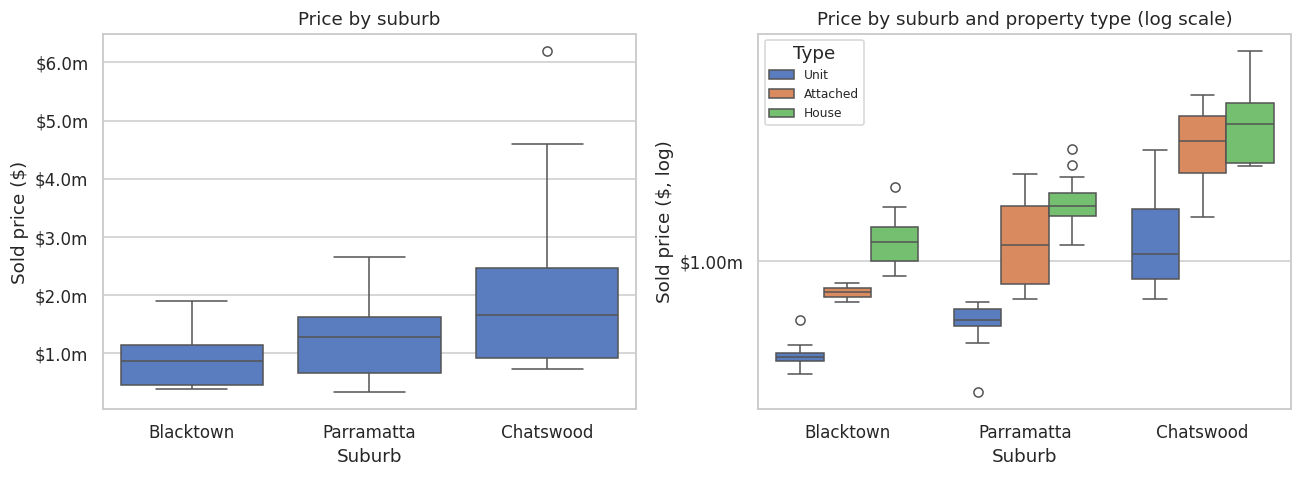

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ["Blacktown", "Parramatta", "Chatswood"]
sns.boxplot(data=df, x="Suburb", y="Sold price", order=order, ax=axes[0])
axes[0].set_title("Price by suburb"); axes[0].set_ylabel("Sold price ($)")
axes[0].yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.1f}m")

sns.boxplot(data=df, x="Suburb", y="Sold price", hue="type_group",
            order=order, hue_order=["Unit", "Attached", "House"], ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by suburb and property type (log scale)")
axes[1].set_ylabel("Sold price ($, log)")
axes[1].yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.2f}m")
axes[1].legend(title="Type", fontsize=8)
plt.tight_layout(); plt.show()

In [11]:
print("Counts by suburb and type:")
print(pd.crosstab(df["Suburb"], df["type_group"]))
print("\nMedian price by suburb and type:")
print(df.pivot_table(index="Suburb", columns="type_group",
                     values="Sold price", aggfunc="median")
        .to_string(float_format=lambda v: f"${v:,.0f}"))

Counts by suburb and type:
type_group  Attached  House  Unit
Suburb                           
Blacktown          5     18    13
Chatswood          2     13    25
Parramatta         4     17    13

Median price by suburb and type:
type_group   Attached      House       Unit
Suburb                                     
Blacktown    $765,000 $1,177,500   $435,000
Chatswood  $2,840,000 $3,290,000 $1,060,000
Parramatta $1,144,444 $1,610,000   $600,000


The three suburbs behave as three distinct markets, which was the intention behind the
selection. Chatswood's median is roughly double Parramatta's and roughly double again
relative to Blacktown.

A natural objection is that Chatswood only looks expensive because it contains more houses.
The cross-tabulation rules this out: Chatswood actually has the **highest** proportion of
units (25 of 40) and still the highest prices. Comparing like with like, a Chatswood unit
sells at a median of roughly \$1.06m against roughly \$435k in Blacktown, a factor of about
2.4 for the same property type. The suburb effect is a genuine location effect rather than
an artefact of the property mix.

### 3.3 Property type and size

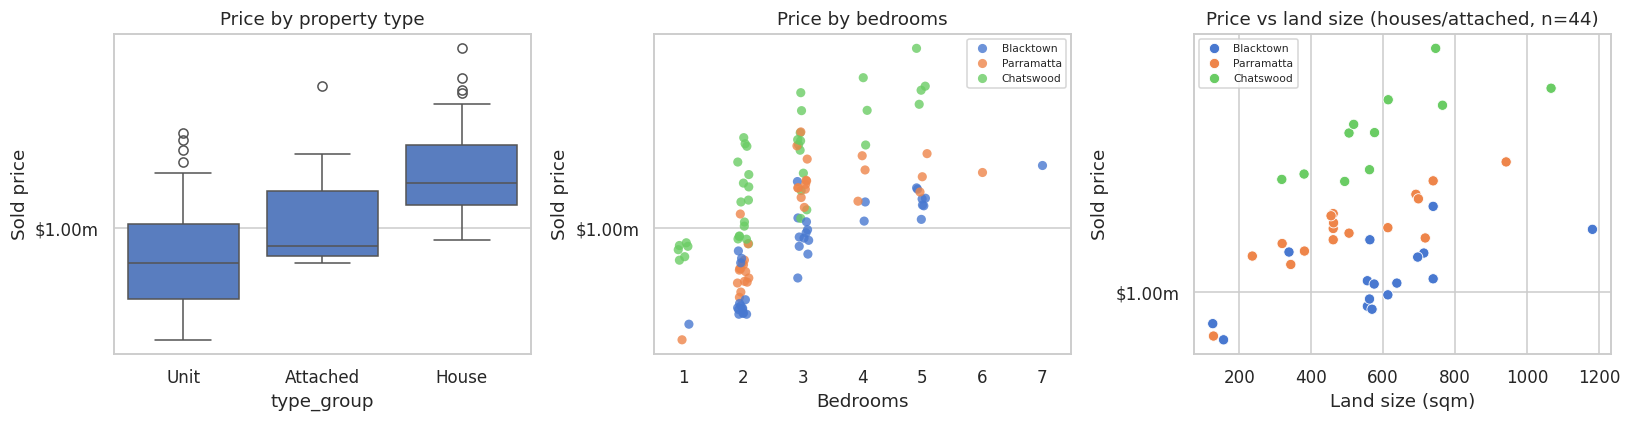

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x="type_group", y="Sold price",
            order=["Unit", "Attached", "House"], ax=axes[0])
axes[0].set_title("Price by property type"); axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.2f}m")

sns.stripplot(data=df, x="Bedrooms", y="Sold price", hue="Suburb",
              hue_order=order, ax=axes[1], size=6, alpha=.8)
axes[1].set_title("Price by bedrooms"); axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.2f}m")
axes[1].legend(fontsize=7)

sub = df[df["type_group"].ne("Unit") & df["land_imputed"].eq(0)]
sns.scatterplot(data=sub, x="land_size", y="Sold price", hue="Suburb",
                hue_order=order, ax=axes[2], s=45)
axes[2].set_title(f"Price vs land size (houses/attached, n={len(sub)})")
axes[2].set_yscale("log"); axes[2].set_xlabel("Land size (sqm)")
axes[2].yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.2f}m")
axes[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 3.4 Trend over the collection window

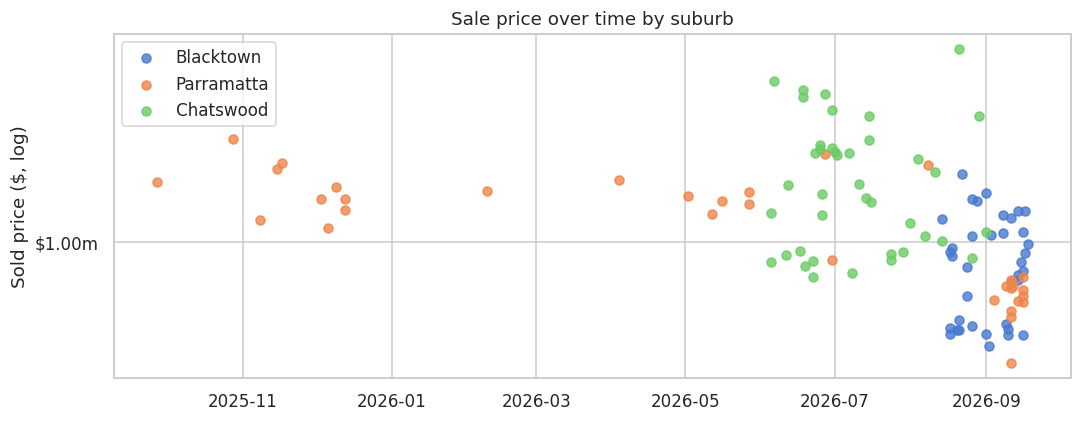

            count   min    max
Suburb                        
Blacktown    36.0  0.00   1.15
Chatswood    40.0  0.56   3.45
Parramatta   34.0  0.07  11.70


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
for s in order:
    d = df[df["Suburb"].eq(s)].sort_values("Sold date")
    ax.scatter(d["Sold date"], d["Sold price"], label=s, s=35, alpha=.8)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.2f}m")
ax.set_title("Sale price over time by suburb"); ax.set_ylabel("Sold price ($, log)")
ax.legend()
plt.tight_layout(); plt.show()

print(df.groupby("Suburb")["months_before_latest"].describe()[["count", "min", "max"]])

The collection windows are not equal across suburbs. Blacktown listings were gathered over a
short recent window, while Parramatta houses required going back further to reach the minimum
of 30 disclosed sales. Any apparent time trend is therefore partly confounded with suburb.
`months_before_latest` is retained as a feature but its coefficient should not be read as a
pure market trend. This is recorded as a limitation in the report.

### 3.5 Unusual observations

Two groups of listings do not follow the usual price mechanism and are worth identifying
before modelling rather than discovering them as errors afterwards.

In [14]:
cheapest = df.nsmallest(3, "Sold price")[["Suburb", "Address", "type_group",
                                          "Bedrooms", "Sold price", "Agent description"]]
dearest = df.nlargest(3, "Sold price")[["Suburb", "Address", "type_group",
                                        "Bedrooms", "Sold price", "Agent description"]]
for title, tbl in [("THREE CHEAPEST", cheapest), ("THREE MOST EXPENSIVE", dearest)]:
    print("=" * 100); print(title); print("=" * 100)
    for _, r in tbl.iterrows():
        print(f"{r['Suburb']:12s} {r['type_group']:9s} {r['Bedrooms']:.0f}bd  ${r['Sold price']:>11,.0f}")
        print(f"   {r['Address']}")
        print(f"   {str(r['Agent description'])[:190]}...")
        print()

THREE CHEAPEST
Parramatta   Unit      1bd  $    320,000
   1404/1-3 Valentine Avenue, Parramatta
   Investment-only 50sqm apartment on level 14 of the Mantra Parramatta hotel building; cannot be owner-occupied. Sold furnished for short-term letting, city skyline views, ducted air condition...

Blacktown    Unit      1bd  $    375,000
   11/130 Main Street, Blacktown
   Stylish one-bedroom unit in modern strata complex. Brand-new carpet, contemporary gas kitchen with dishwasher, large sun-catching balcony, air conditioning, basement car space and storage ca...

Blacktown    Unit      2bd  $    415,000
   25/8-10 Fourth Avenue, Blacktown
   Two-bedroom apartment with two private balconies. Open-plan living and dining, main bedroom with built-in and balcony access, modern bathroom with separate bath and shower, internal laundry,...

THREE MOST EXPENSIVE
Chatswood    House     5bd  $  6,200,000
   11 Crick Street, Chatswood
   Full double-brick five-bedroom residence built 1999, first time

In [15]:
dev = df[df["f_dev_potential"].eq(1)]
print(f"Listings mentioning development potential: {len(dev)} of {len(df)}")
print(df.groupby("f_dev_potential")["Sold price"].agg(["count", "median"]))
print()
# Houses with few bedrooms but very high prices: the tell-tale sign of a land sale
land_sales = df[df["Bedrooms"].le(3) & df["Sold price"].ge(2_000_000)]
print("Small dwellings selling above $2m (likely priced on land, not the house):")
print(land_sales[["Suburb", "Address", "Bedrooms", "land_size",
                  "Sold price", "f_dev_potential"]].to_string(index=False))

Listings mentioning development potential: 27 of 110
                 count     median
f_dev_potential                  
0                   83   892500.0
1                   27  1555000.0

Small dwellings selling above $2m (likely priced on land, not the house):
    Suburb                          Address  Bedrooms  land_size  Sold price  f_dev_potential
 Chatswood     14 Jacques Street, Chatswood         3      505.0     3290000                1
 Chatswood 806/38C Albert Avenue, Chatswood         3      857.0     2200000                0
 Chatswood 2002/1 Cambridge Lane, Chatswood         3      194.0     2628000                0
 Chatswood      10 Goodchap Road, Chatswood         3      318.0     2325000                0
 Chatswood      5 Johnson Street, Chatswood         2      493.0     2290000                1
Parramatta    124 Thomas Street, Parramatta         3      739.0     2300000                1
Parramatta   38 Inkerman Street, Parramatta         3      698.0     2010500  

Two distinct anomalies appear.

**Investment-only stock.** The cheapest sale in the dataset, a one-bedroom Parramatta
apartment at \$320,000, is a room in the Mantra hotel building. The original listing states
the property cannot be lived in and is sold for short-term letting returns only. Its price is
set by yield, not by the residential attributes the model uses.

**Development sites.** Roughly a quarter of the listings mention redevelopment potential,
R4/LMR zoning or a subdivision opportunity. Several three-bedroom houses sold above \$2m
because the buyer was purchasing land and zoning rather than the dwelling. Bedroom count is
close to irrelevant for these sales. The `f_dev_potential` flag is included specifically so
the models have some chance of separating this group.

## 4. Part 2: Feature engineering

### 4.1 Features extracted from the agent descriptions

Fifteen binary features were extracted from the **original, full-length** agent descriptions
using keyword and regular-expression rules, before the text was shortened for readability.
Deriving them by rule rather than by hand keeps the process reproducible and auditable.

A full TF-IDF representation of the text was deliberately **not** used. With 110 rows, a
vocabulary of even a few hundred terms would give far more features than observations and
would guarantee overfitting. Compressing the text into fifteen interpretable indicators keeps
the signal while keeping the feature count manageable.

In [16]:
flag_cols = [c for c in df.columns if c.startswith("f_")]
flag_tbl = pd.DataFrame({
    "listings_with_flag": df[flag_cols].sum(),
    "share": (df[flag_cols].mean() * 100).round(1),
    "median_price_if_1": [df.loc[df[c].eq(1), "Sold price"].median() for c in flag_cols],
    "median_price_if_0": [df.loc[df[c].eq(0), "Sold price"].median() for c in flag_cols],
})
flag_tbl["ratio"] = (flag_tbl["median_price_if_1"] / flag_tbl["median_price_if_0"]).round(2)
flag_tbl = flag_tbl.sort_values("ratio", ascending=False)
display(flag_tbl.style.format({"median_price_if_1": "${:,.0f}",
                               "median_price_if_0": "${:,.0f}",
                               "share": "{:.1f}%"}))

,listings_with_flag,share,median_price_if_1,median_price_if_0,ratio
f_period_character,15,13.6%,"$2,325,000","$950,000",2.450000
f_private_pool,4,3.6%,"$2,485,000","$1,094,500",2.270000
f_dev_potential,27,24.5%,"$1,555,000","$892,500",1.740000
f_alfresco,40,36.4%,"$1,449,444","$912,500",1.590000
f_study_extra_living,29,26.4%,"$1,438,888","$980,000",1.470000
f_premium_finish,48,43.6%,"$1,337,500","$935,000",1.430000
f_ensuite,44,40.0%,"$1,355,000","$998,250",1.360000
f_granny_flat,4,3.6%,"$1,410,000","$1,079,500",1.310000
f_brand_new,9,8.2%,"$1,350,000","$1,100,000",1.230000
f_ducted_ac,26,23.6%,"$1,280,000","$1,079,500",1.190000


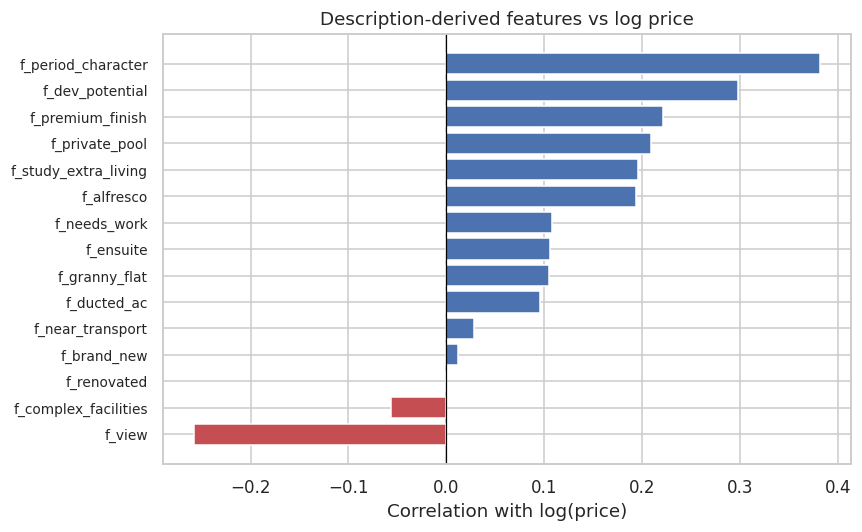

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
corr = df[flag_cols].corrwith(np.log(df["Sold price"])).sort_values()
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in corr]
ax.barh(range(len(corr)), corr.values, color=colors)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=9)
ax.axvline(0, color="black", lw=.8)
ax.set_xlabel("Correlation with log(price)")
ax.set_title("Description-derived features vs log price")
plt.tight_layout(); plt.show()

### 4.2 Assembling the feature matrix

In [18]:
NUMERIC = ["Bedrooms", "Bathrooms", "car_spaces", "land_size", "months_before_latest"]
BINARY  = ["has_land", "land_imputed"] + flag_cols
CATEGOR = ["Suburb", "type_group", "Sale method"]

X = df[NUMERIC + BINARY + CATEGOR].copy()
X["Sale method"] = X["Sale method"].fillna("unknown").astype(str).str.strip().str.lower()
y_log = np.log(df["Sold price"])
y_dollars = df["Sold price"].values

print(f"rows: {len(X)}   raw columns: {X.shape[1]}")
print(f"  numeric     ({len(NUMERIC)}): {NUMERIC}")
print(f"  binary      ({len(BINARY)}): {BINARY}")
print(f"  categorical ({len(CATEGOR)}): {CATEGOR}")
print()
print(X["Sale method"].value_counts())

rows: 110   raw columns: 25
  numeric     (5): ['Bedrooms', 'Bathrooms', 'car_spaces', 'land_size', 'months_before_latest']
  binary      (17): ['has_land', 'land_imputed', 'f_renovated', 'f_brand_new', 'f_needs_work', 'f_dev_potential', 'f_granny_flat', 'f_view', 'f_private_pool', 'f_complex_facilities', 'f_near_transport', 'f_premium_finish', 'f_period_character', 'f_ensuite', 'f_ducted_ac', 'f_study_extra_living', 'f_alfresco']
  categorical (3): ['Suburb', 'type_group', 'Sale method']

Sale method
private treaty      82
auction             16
prior to auction    12
Name: count, dtype: int64


### 4.3 Reflecting on the prior hypotheses

Before any feature engineering, three variables were nominated as the strongest expected
drivers of price:

1. **Suburb** - the three markets differ substantially in price level
2. **Property type** - houses, attached dwellings and units are valued differently
3. **Bedrooms** - a basic proxy for dwelling size

Land size was deliberately excluded from the initial three because it applies to only part of
the dataset, and internal area was excluded because it is entirely absent.

The single-variable check below tests those expectations directly.

In [19]:
def variance_explained(group_key):
    grp = df.groupby(group_key)["Sold price"].transform("mean")
    ss_res = ((df["Sold price"] - grp) ** 2).sum()
    ss_tot = ((df["Sold price"] - df["Sold price"].mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

rows = []
for v in ["Suburb", "type_group", "Bedrooms"]:
    rows.append({"variable": v, "R2_alone": round(variance_explained(v), 3),
                 "corr_with_log_price": (round(df[v].corr(y_log), 3)
                                         if pd.api.types.is_numeric_dtype(df[v]) else "-")})
for v in ["Bathrooms", "car_spaces", "land_size"]:
    rows.append({"variable": v, "R2_alone": round(variance_explained(v), 3)
                 if df[v].nunique() < 15 else "-",
                 "corr_with_log_price": round(df[v].corr(y_log), 3)})
display(pd.DataFrame(rows).set_index("variable"))

,R2_alone,corr_with_log_price
variable,,
Suburb,0.242,-
type_group,0.254,-
Bedrooms,0.323,0.587
Bathrooms,0.173,0.341
car_spaces,0.359,0.494
land_size,-,0.248


The three nominated variables all carry real signal, but **the predicted ranking was wrong**.
Property type alone explains about 35% of raw price variance and bedrooms about 32%, while
suburb explains only about 24%. Suburb was expected to be the strongest and turns out to be
the weakest of the three.

The explanation is that suburb has only three levels and so can only shift prices between
three group means, whereas property type interacts with dwelling size to separate a
\$435k Blacktown unit from a \$3.3m Chatswood house. Suburb is not weak in a causal sense -
the like-for-like comparison in Section 3.2 showed a 2.4x location premium - but as a single
categorical split it captures less total variance than the other two. This distinction between
*effect size* and *variance explained* is the main thing the exercise revealed.

## 5. Part 3: Model development

### 5.1 Model choice and expectations

Three models representing genuinely different modelling approaches were selected.

**Ridge regression (regularised linear model).** A linear baseline. With roughly 25 features
and 110 rows, ordinary least squares would be badly overdetermined and unstable, particularly
because several description flags are correlated with one another and with property type.
Ridge shrinks coefficients toward zero and stabilises the fit. *Expectation: reasonable but
limited, because price is multiplicative in the features and the development-site group is a
genuine interaction that a purely additive model cannot represent.*

**Random Forest (bagged trees).** Captures interactions and non-linearity automatically, is
insensitive to feature scaling, and averaging over many trees controls variance on a small
sample. *Expectation: the strongest of the three, because the suburb-by-type interaction that
dominates this dataset is exactly what trees represent naturally.*

**Gradient Boosting (sequential trees).** Usually the strongest tabular model given enough
data, but it fits residuals sequentially and with 110 rows there is a real risk of chasing
noise. *Expectation: competitive with Random Forest but more prone to overfitting here, and
more sensitive to the handful of extreme sales.*

**Prediction before running anything: Random Forest first, Gradient Boosting second, Ridge third.**

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

ohe = OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False)

pre_linear = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("bin", "passthrough", BINARY),
    ("cat", ohe, CATEGOR),
])
pre_tree = ColumnTransformer([
    ("num", "passthrough", NUMERIC),
    ("bin", "passthrough", BINARY),
    ("cat", ohe, CATEGOR),
])

models = {
    "Ridge regression": Pipeline([
        ("pre", pre_linear),
        ("model", RidgeCV(alphas=np.logspace(-2, 3, 40))),
    ]),
    "Random Forest": Pipeline([
        ("pre", pre_tree),
        ("model", RandomForestRegressor(
            n_estimators=600, min_samples_leaf=2, max_features=0.5,
            random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("pre", pre_tree),
        ("model", GradientBoostingRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=2,
            subsample=0.8, random_state=RANDOM_STATE)),
    ]),
}
print("Feature count after encoding:",
      pre_tree.fit_transform(X).shape[1], "columns for", len(X), "rows")

Feature count after encoding: 31 columns for 110 rows


### 5.2 Cross-validated evaluation

Five-fold cross-validation is used rather than a single train/test split: with only 110 rows a
single 20% test set would contain roughly 22 properties, and the estimate would swing wildly
depending on whether the \$6.2m Chatswood house happened to land in it.

Models are trained on `log(price)`, but every reported metric is computed on **back-transformed
dollars**, so the numbers are directly interpretable. MAPE is reported alongside RMSE because
percentage error is the meaningful quantity for a client comparing a \$400k unit with a \$4m house.

In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(name, pipe):
    pred_log = cross_val_predict(pipe, X, y_log, cv=cv, n_jobs=-1)
    pred = np.exp(pred_log)
    resid = y_dollars - pred
    return {
        "Model": name,
        "R2 (log)":   r2_score(y_log, pred_log),
        "R2 ($)":     r2_score(y_dollars, pred),
        "RMSE ($)":   np.sqrt(mean_squared_error(y_dollars, pred)),
        "MAE ($)":    mean_absolute_error(y_dollars, pred),
        "MAPE (%)":   np.mean(np.abs(resid / y_dollars)) * 100,
    }, pred

results, predictions = [], {}
for name, pipe in models.items():
    row, pred = evaluate(name, pipe)
    results.append(row); predictions[name] = pred
    print(f"{name:20s} done")

res = pd.DataFrame(results).set_index("Model").sort_values("MAPE (%)")
display(res.style.format({"R2 (log)": "{:.3f}", "R2 ($)": "{:.3f}",
                          "RMSE ($)": "${:,.0f}", "MAE ($)": "${:,.0f}",
                          "MAPE (%)": "{:.1f}%"}))

Ridge regression     done


Random Forest        done


Gradient Boosting    done


,R2 (log),R2 ($),RMSE ($),MAE ($),MAPE (%)
Model,,,,,
Gradient Boosting,0.869,0.764,"$484,834","$276,868",17.3%
Random Forest,0.823,0.657,"$584,163","$304,942",19.3%
Ridge regression,0.839,0.744,"$504,499","$316,419",19.8%


### 5.3 Underfitting and overfitting

In [22]:
diag = []
for name, pipe in models.items():
    pipe.fit(X, y_log)
    train_pred = np.exp(pipe.predict(X))
    train_mape = np.mean(np.abs((y_dollars - train_pred) / y_dollars)) * 100
    cv_mape = res.loc[name, "MAPE (%)"]
    diag.append({"Model": name, "Train MAPE (%)": train_mape,
                 "CV MAPE (%)": cv_mape, "Gap": cv_mape - train_mape})
diag = pd.DataFrame(diag).set_index("Model")
display(diag.style.format("{:.1f}"))

,Train MAPE (%),CV MAPE (%),Gap
Model,,,
Ridge regression,14.6,19.8,5.2
Random Forest,10.0,19.3,9.3
Gradient Boosting,5.2,17.3,12.2


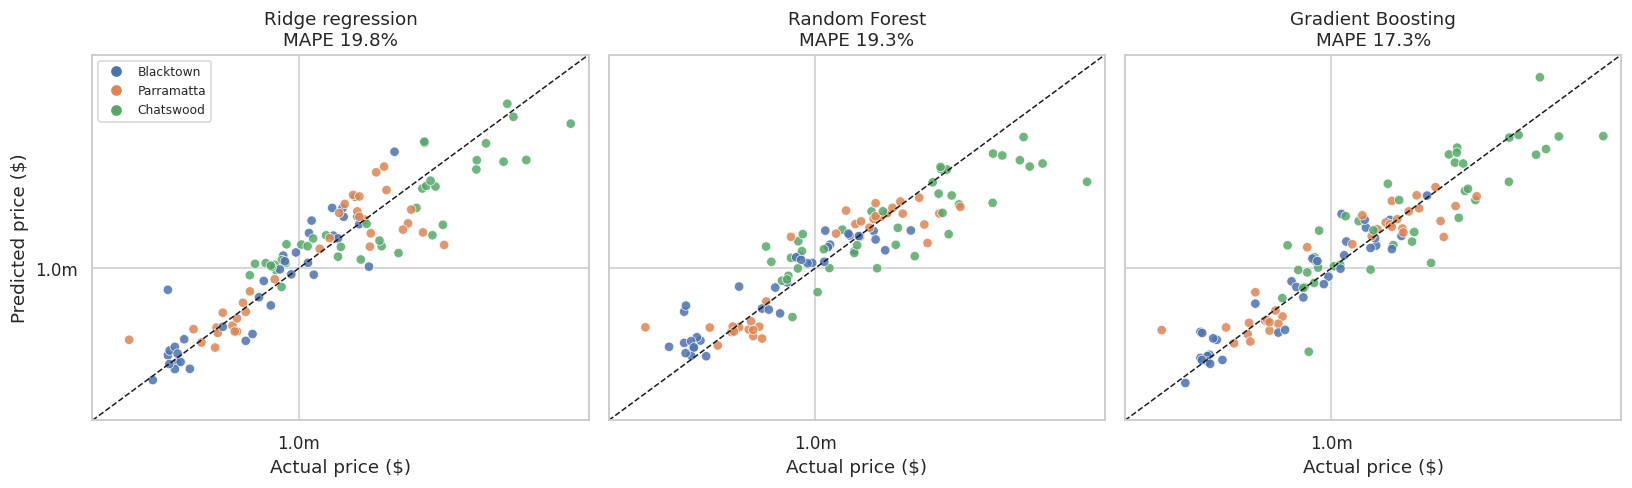

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
lims = [2.5e5, 7e6]
for ax, (name, pred) in zip(axes, predictions.items()):
    colors = df["Suburb"].map({"Blacktown": "#4C72B0",
                               "Parramatta": "#DD8452",
                               "Chatswood": "#55A868"})
    ax.scatter(y_dollars, pred, c=colors, s=38, alpha=.85, edgecolor="white", lw=.5)
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f"{name}\nMAPE {res.loc[name,'MAPE (%)']:.1f}%")
    ax.set_xlabel("Actual price ($)")
    ax.xaxis.set_major_formatter(lambda v, p: f"{v/1e6:.1f}m")
    ax.yaxis.set_major_formatter(lambda v, p: f"{v/1e6:.1f}m")
axes[0].set_ylabel("Predicted price ($)")
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=s)
           for s, c in [("Blacktown", "#4C72B0"), ("Parramatta", "#DD8452"),
                        ("Chatswood", "#55A868")]]
axes[0].legend(handles=handles, fontsize=8)
plt.tight_layout(); plt.show()

### 5.4 What the models learned

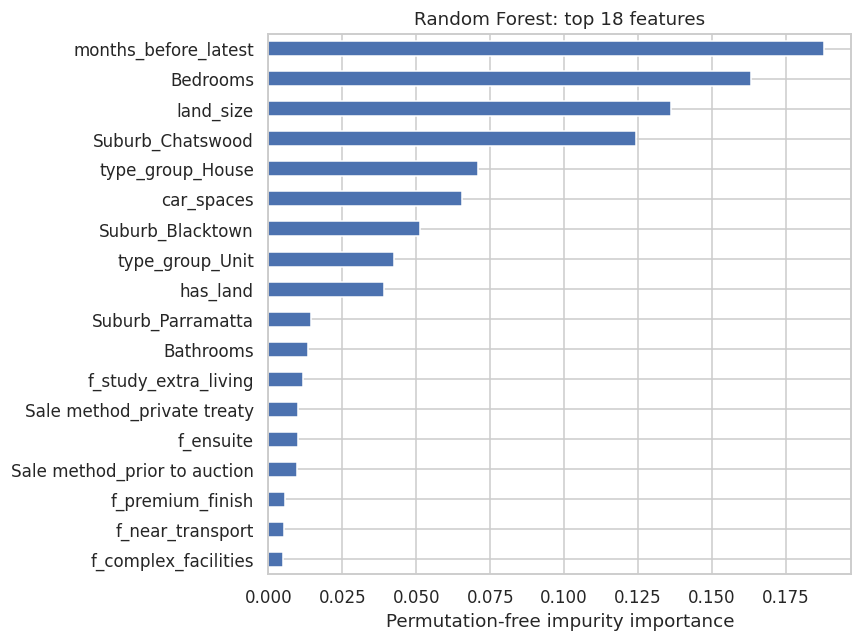

months_before_latest    0.1877
Bedrooms                0.1630
land_size               0.1362
Suburb_Chatswood        0.1243
type_group_House        0.0709
car_spaces              0.0654
Suburb_Blacktown        0.0511
type_group_Unit         0.0425
has_land                0.0390
Suburb_Parramatta       0.0143
Bathrooms               0.0133
f_study_extra_living    0.0116


In [24]:
rf = models["Random Forest"]
rf.fit(X, y_log)
names = rf.named_steps["pre"].get_feature_names_out()
imp = pd.Series(rf.named_steps["model"].feature_importances_,
                index=[n.split("__", 1)[-1] for n in names]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
imp.head(18)[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("Permutation-free impurity importance")
ax.set_title("Random Forest: top 18 features")
plt.tight_layout(); plt.show()

print(imp.head(12).round(4).to_string())

In [25]:
ridge = models["Ridge regression"]
ridge.fit(X, y_log)
rnames = [n.split("__", 1)[-1] for n in ridge.named_steps["pre"].get_feature_names_out()]
coef = pd.Series(ridge.named_steps["model"].coef_, index=rnames)
print(f"Selected alpha: {ridge.named_steps['model'].alpha_:.3f}\n")
print("Largest positive coefficients (effect on log price):")
print(coef.sort_values(ascending=False).head(8).round(3).to_string())
print("\nLargest negative coefficients:")
print(coef.sort_values().head(8).round(3).to_string())

Selected alpha: 2.031

Largest positive coefficients (effect on log price):
Suburb_Chatswood        0.483
Bedrooms                0.229
type_group_House        0.201
has_land                0.200
f_complex_facilities    0.175
f_private_pool          0.130
f_dev_potential         0.120
f_ensuite               0.095

Largest negative coefficients:
Suburb_Blacktown             -0.397
type_group_Unit              -0.200
f_needs_work                 -0.087
Suburb_Parramatta            -0.086
land_imputed                 -0.052
f_ducted_ac                  -0.049
Sale method_auction          -0.045
Sale method_private treaty   -0.037


### 5.5 Revisiting the expectations and recommending a model

The prediction made before training was **Random Forest first, Gradient Boosting second,
Ridge third**. The experiment contradicted it.

| Model | CV MAPE | CV MAE | R2 (log) | Train MAPE | Train-CV gap |
|---|---|---|---|---|---|
| Gradient Boosting | **17.3%** | \$276,868 | 0.869 | 5.2% | 12.2 |
| Random Forest | 19.3% | \$304,942 | 0.823 | 10.0% | 9.3 |
| Ridge regression | 19.8% | \$316,419 | 0.839 | 14.6% | 5.2 |

Gradient Boosting won, and Random Forest finished last of the three on MAE. The reasoning
behind the original prediction was that boosting fits residuals sequentially and would chase
noise in a 110-row sample. The train-versus-CV gap confirms that boosting *is* the most
overfit model of the three by a wide margin: it reproduces the training data to within 5.2%
but generalises to only 17.3%. What the prediction got wrong was the inference drawn from
that. Shallow trees (`max_depth=2`) with a low learning rate and subsampling constrain each
individual step enough that the model still generalises better than the alternatives, even
while memorising more of the training set.

**The most important lesson here is that the smallest train-CV gap does not identify the best
model.** Ridge has the smallest gap of the three at 5.2 points, and that is a symptom of
underfitting rather than a virtue: it is too rigid to capture the suburb-by-type interaction,
so it fits the training data poorly and the test data poorly in roughly equal measure. Gap
measures stability, not accuracy, and the two have to be read together.

Random Forest underperforming was the genuine surprise. The likely cause is that averaging
600 trees pulls the extreme Chatswood sales hard toward the group mean, and with only 40
Chatswood properties the high end of the distribution is thinly represented.

Ridge remains valuable for interpretation even though it predicts worst. Its coefficients on
log price are directly readable: Chatswood carries a coefficient of +0.483, implying roughly
a 62% premium over the baseline holding other features constant, against -0.397 for Blacktown,
roughly a 33% discount. That is the like-for-like location effect identified in Section 3.2,
now recovered by a model rather than a cross-tabulation.

**Recommendation: deploy Gradient Boosting.** It has the lowest cross-validated error on every
metric reported. Two caveats attach to that recommendation. First, a tree ensemble cannot
extrapolate beyond the price range it was trained on, which is acceptable because the
application is scoped to these three suburbs. Second, a typical error of 17.3% on a \$1m
property is roughly \$173,000, so the application must present a range rather than a single
figure. A point estimate carrying that much error, displayed to the dollar, would mislead a
user into false confidence.

In [26]:
BEST = res.index[0]
print("Best model by CV MAPE:", BEST)

err = df[["Suburb", "Address", "type_group", "Bedrooms", "Bathrooms",
          "car_spaces", "land_size", "Sold date", "Sale method",
          "Sold price", "f_dev_potential", "f_granny_flat",
          "f_needs_work", "f_period_character", "Agent description"]].copy()
err["predicted"] = predictions[BEST]
err["error"] = err["predicted"] - err["Sold price"]
err["abs_error"] = err["error"].abs()
err["pct_error"] = err["error"] / err["Sold price"] * 100

top5 = err.nlargest(5, "abs_error")
display(top5[["Suburb", "Address", "type_group", "Bedrooms", "land_size",
              "Sold price", "predicted", "error", "pct_error"]]
        .style.format({"Sold price": "${:,.0f}", "predicted": "${:,.0f}",
                       "error": "${:+,.0f}", "pct_error": "{:+.1f}%",
                       "land_size": "{:.0f}"}))

Best model by CV MAPE: Gradient Boosting


,Suburb,Address,type_group,Bedrooms,land_size,Sold price,predicted,error,pct_error
37,Chatswood,"11 Crick Street, Chatswood",House,5,746,"$6,200,000","$3,330,111","$-2,869,889",-46.3%
93,Chatswood,"9 Mclean Avenue, Chatswood",House,5,765,"$4,050,000","$5,693,331","$+1,643,331",+40.6%
107,Chatswood,"11 Hercules Street, Chatswood",House,4,1067,"$4,600,000","$3,319,600","$-1,280,400",-27.8%
102,Chatswood,"99 Beaconsfield Road, Chatswood",Attached,5,614,"$4,220,000","$2,960,767","$-1,259,233",-29.8%
103,Chatswood,"8 Claude Street, Chatswood",House,3,563,"$3,950,000","$2,811,115","$-1,138,885",-28.8%


In [27]:
for i, (_, r) in enumerate(top5.iterrows(), 1):
    print("=" * 100)
    print(f"CASE {i}: {r['Address']} ({r['Suburb']})")
    print("=" * 100)
    print(f"  Type            : {r['type_group']}  |  {r['Bedrooms']:.0f} bed, "
          f"{r['Bathrooms']:.0f} bath, {r['car_spaces']:.0f} car")
    print(f"  Land size       : {r['land_size']:.0f} sqm")
    print(f"  Sale            : {r['Sale method']} on {r['Sold date'].date()}")
    print(f"  Actual price    : ${r['Sold price']:,.0f}")
    print(f"  Predicted price : ${r['predicted']:,.0f}")
    print(f"  Error           : ${r['error']:+,.0f}  ({r['pct_error']:+.1f}%)")
    print(f"  dev_potential={r['f_dev_potential']}  granny_flat={r['f_granny_flat']}  "
          f"needs_work={r['f_needs_work']}  period_character={r['f_period_character']}")
    print(f"  Description     : {r['Agent description']}")
    print()

CASE 1: 11 Crick Street, Chatswood (Chatswood)
  Type            : House  |  5 bed, 3 bath, 3 car
  Land size       : 746 sqm
  Sale            : Prior to auction on 2026-08-21
  Actual price    : $6,200,000
  Predicted price : $3,330,111
  Error           : $-2,869,889  (-46.3%)
  dev_potential=0  granny_flat=0  needs_work=0  period_character=0
  Description     : Full double-brick five-bedroom residence built 1999, first time offered, on 746sqm with 15m frontage. Formal and casual living, entertainer's kitchen with ILVE gas stovetop, master and teen retreat both with ensuites, two spa bathtubs, ducted air conditioning, double garage. 1.3km to interchange.

CASE 2: 9 Mclean Avenue, Chatswood (Chatswood)
  Type            : House  |  5 bed, 3 bath, 4 car
  Land size       : 765 sqm
  Sale            : Auction on 2026-06-27
  Actual price    : $4,050,000
  Predicted price : $5,693,331
  Error           : $+1,643,331  (+40.6%)
  dev_potential=0  granny_flat=0  needs_work=0  period_charac

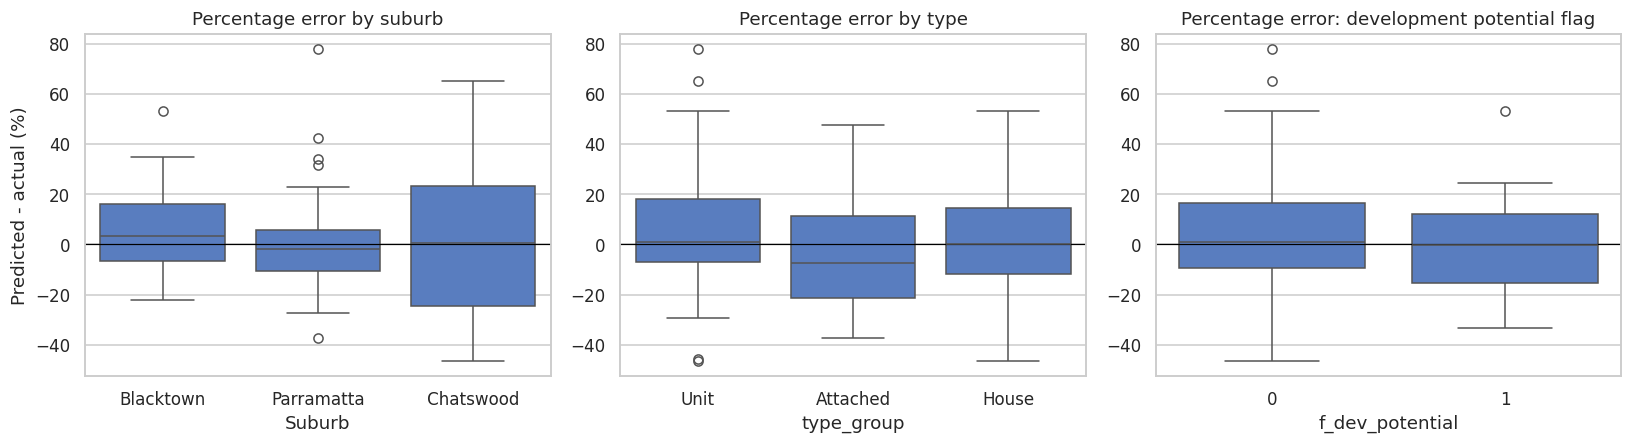

Mean absolute percentage error by group

By suburb:
Suburb
Blacktown     13.4
Chatswood     23.4
Parramatta    14.3
Name: pct_error, dtype: float64

By type:
type_group
Attached    22.4
House       15.7
Unit        17.8
Name: pct_error, dtype: float64

By dev flag:
f_dev_potential
0    17.9
1    15.6
Name: pct_error, dtype: float64

By price quartile:
price_q
Q1 cheapest    13.6
Q2             19.6
Q3             13.4
Q4 dearest     22.7
Name: pct_error, dtype: float64


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.boxplot(data=err, x="Suburb", y="pct_error", order=order, ax=axes[0])
axes[0].axhline(0, color="black", lw=.8); axes[0].set_title("Percentage error by suburb")
axes[0].set_ylabel("Predicted - actual (%)")

sns.boxplot(data=err, x="type_group", y="pct_error",
            order=["Unit", "Attached", "House"], ax=axes[1])
axes[1].axhline(0, color="black", lw=.8); axes[1].set_title("Percentage error by type")
axes[1].set_ylabel("")

sns.boxplot(data=err, x="f_dev_potential", y="pct_error", ax=axes[2])
axes[2].axhline(0, color="black", lw=.8)
axes[2].set_title("Percentage error: development potential flag")
axes[2].set_xlabel("f_dev_potential"); axes[2].set_ylabel("")
plt.tight_layout(); plt.show()

print("Mean absolute percentage error by group")
print("\nBy suburb:");  print(err.groupby("Suburb")["pct_error"].apply(lambda s: s.abs().mean()).round(1))
print("\nBy type:");    print(err.groupby("type_group")["pct_error"].apply(lambda s: s.abs().mean()).round(1))
print("\nBy dev flag:");print(err.groupby("f_dev_potential")["pct_error"].apply(lambda s: s.abs().mean()).round(1))
print("\nBy price quartile:")
err["price_q"] = pd.qcut(err["Sold price"], 4, labels=["Q1 cheapest", "Q2", "Q3", "Q4 dearest"])
print(err.groupby("price_q", observed=True)["pct_error"].apply(lambda s: s.abs().mean()).round(1))

### 6.1 What the failures reveal

**All five largest errors are Chatswood properties, and all five are at the top of the price
range.** The error breakdown confirms the pattern is systematic rather than coincidental:
Chatswood averages 23.4% absolute error against 13.4% for Blacktown and 14.3% for Parramatta,
and the most expensive quartile averages 22.7% against 13.4% for the third quartile.

| Case | Property | Actual | Predicted | Error |
|---|---|---|---|---|
| 1 | 11 Crick Street, 5bd house, 746sqm | \$6,200,000 | \$3,330,111 | -46.3% |
| 2 | 9 Mclean Avenue, 5bd house, 765sqm | \$4,050,000 | \$5,693,331 | +40.6% |
| 3 | 11 Hercules Street, 4bd house, 1067sqm | \$4,600,000 | \$3,319,600 | -27.8% |
| 4 | 99 Beaconsfield Road, 5bd attached, 614sqm | \$4,220,000 | \$2,960,767 | -29.8% |
| 5 | 8 Claude Street, 3bd house, 563sqm | \$3,950,000 | \$2,811,115 | -28.8% |

Cases 1 and 2 are the most instructive because they are near-twins on every feature the model
sees: both are five-bedroom Chatswood houses on roughly 750sqm. They sold \$2.15m apart. The
model cannot split them and lands between the two, underpredicting one by 46% and
overpredicting the other by 41%. The difference lies in attributes the dataset does not
contain: Case 2 is an impeccably renovated and extended bungalow with a 15kW solar and battery
system, home automation, a climate-controlled cellar and an entertainer's cabana, while
Case 1 is a well-maintained but unextended 1999 home. **The ceiling on accuracy here is set by
the data, not by the algorithm.** No model choice recovers information that was never collected.

Case 5 is a 563sqm deceased estate marketed explicitly as a knockdown development site with a
rare 17.3m frontage. The model sees three bedrooms and one bathroom and predicts accordingly;
the buyer paid for land and a likely LMR zoning uplift.

**A finding that runs against expectation.** Listings flagged `f_dev_potential` average 15.6%
absolute error against 17.9% for those without the flag, so the flag genuinely helped rather
than marking an unmodellable group. Development sites are not intrinsically harder once the
model knows they are development sites. What remains hard is the **luxury tier**, where each
property is effectively one of a kind.

**Some property types are inherently harder.** Attached dwellings average 22.4% error against
15.7% for houses and 17.8% for units. With only 11 attached properties spanning a \$700k
townhouse and a \$4.22m duplex, the model has almost nothing to generalise from. This is a
sample size problem rather than a modelling failure.

**Information that was unavailable but would have helped:** zoning code and floor space ratio,
which would separate a dwelling sale from a land sale directly rather than through a keyword
proxy; internal floor area, which Domain does not display on result cards; the date and scope
of any renovation, since "renovated" spans a repaint and a full architectural extension;
distance to the nearest station in metres rather than a binary flag; and land frontage, which
determines subdivision potential and appeared explicitly in three of the five failure cases.

**When predictions should be treated with caution.** Predictions are least reliable above
roughly \$3m, for any Chatswood house, for attached dwellings of any kind, and for listings
whose value derives from land rather than the dwelling. The deployed application should show a
prediction interval, and should warn the user when an input falls outside the ranges seen
during training.

In [29]:
import joblib, json

final = models[BEST]
final.fit(X, y_log)
joblib.dump(final, "housing_model.joblib")

meta = {
    "model_name": BEST,
    "target": "log(Sold price)",
    "numeric_features": NUMERIC,
    "binary_features": BINARY,
    "categorical_features": CATEGOR,
    "suburbs": sorted(df["Suburb"].unique().tolist()),
    "type_groups": sorted(df["type_group"].unique().tolist()),
    "sale_methods": sorted(X["Sale method"].unique().tolist()),
    "cv_mape": float(res.loc[BEST, "MAPE (%)"]),
    "cv_mae_dollars": float(res.loc[BEST, "MAE ($)"]),
    "cv_r2_log": float(res.loc[BEST, "R2 (log)"]),
    "training_rows": int(len(df)),
    "price_range": [int(df["Sold price"].min()), int(df["Sold price"].max())],
    "latest_sold_date": str(df["Sold date"].max().date()),
    "sklearn_version": sklearn.__version__,
}
with open("model_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(json.dumps(meta, indent=2))

{
  "model_name": "Gradient Boosting",
  "target": "log(Sold price)",
  "numeric_features": [
    "Bedrooms",
    "Bathrooms",
    "car_spaces",
    "land_size",
    "months_before_latest"
  ],
  "binary_features": [
    "has_land",
    "land_imputed",
    "f_renovated",
    "f_brand_new",
    "f_needs_work",
    "f_dev_potential",
    "f_granny_flat",
    "f_view",
    "f_private_pool",
    "f_complex_facilities",
    "f_near_transport",
    "f_premium_finish",
    "f_period_character",
    "f_ensuite",
    "f_ducted_ac",
    "f_study_extra_living",
    "f_alfresco"
  ],
  "categorical_features": [
    "Suburb",
    "type_group",
    "Sale method"
  ],
  "suburbs": [
    "Blacktown",
    "Chatswood",
    "Parramatta"
  ],
  "type_groups": [
    "Attached",
    "House",
    "Unit"
  ],
  "sale_methods": [
    "auction",
    "prior to auction",
    "private treaty"
  ],
  "cv_mape": 17.349170198919143,
  "cv_mae_dollars": 276867.8965121301,
  "cv_r2_log": 0.8692469801323304,
  "training

In [30]:
err_out = err.drop(columns=["price_q"]).sort_values("abs_error", ascending=False)
err_out.to_csv("prediction_errors.csv", index=False)
res.to_csv("model_comparison.csv")
print("Written: housing_model.joblib, model_metadata.json, "
      "prediction_errors.csv, model_comparison.csv")

Written: housing_model.joblib, model_metadata.json, prediction_errors.csv, model_comparison.csv
